# Deep Learning – Week 9: Text Classification with GloVe & LSTM

**Dataset:** 20 Newsgroups (18,000+ posts across 20 categories)  
**Goal:** Classify newsgroup posts into one of 20 topic categories  
**Architecture:** GloVe pre-trained embeddings (100d) → SpatialDropout1D → LSTM (128 units) → Softmax  

---
## Pipeline Overview
1. Load & explore data
2. Preprocess text (clean, tokenize, pad)
3. Load GloVe embeddings & build embedding matrix
4. Build & train LSTM model with early stopping
5. Evaluate: accuracy, F1, confusion matrix, training curves

In [13]:
import kagglehub
path = kagglehub.dataset_download("crawford/20-newsgroups")

Using Colab cache for faster access to the '20-newsgroups' dataset.


## 1. Imports & Reproducibility

In [1]:
import os, re
import numpy as np
import pandas as pd
import nltk
import tensorflow as tf
from sklearn.datasets import fetch_20newsgroups
from sklearn.metrics import classification_report, confusion_matrix
from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns
import matplotlib.pyplot as plt

# ── Set seeds for reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Download NLTK stopwords
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

print('All imports successful. Seeds set to', SEED)

All imports successful. Seeds set to 42


## 2. Load the 20 Newsgroups Dataset

In [2]:
newsgroups_train = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))
newsgroups_test  = fetch_20newsgroups(subset='test',  remove=('headers', 'footers', 'quotes'))

print('Categories:', newsgroups_train.target_names)
print(f'\nTraining samples : {len(newsgroups_train.data)}')
print(f'Test samples     : {len(newsgroups_test.data)}')
print('\nSample document:\n', newsgroups_train.data[0])

Categories: ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']

Training samples : 11314
Test samples     : 7532

Sample document:
 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.


## 3. Text Preprocessing

**Fix applied:** The original code used `re.sub(r'\s+', '', text)` which *deleted* all whitespace,
merging every word into one long string and breaking tokenization. Corrected to `re.sub(r'\s+', ' ', text)`
which *normalises* whitespace instead. The `join` separator is also changed from `''` to `' '` so
filtered words are space-separated.

In [3]:
def preprocess_text(text):
    # FIX: use ' ' not '' so whitespace is normalised, not deleted
    text = re.sub(r'\s+', ' ', text)          # normalise whitespace
    text = re.sub(r'[^\w\s]', '', text)       # remove punctuation only
    text = text.lower().strip()
    # FIX: join with space so tokens remain separate
    text = ' '.join([w for w in text.split() if w not in stop_words])
    return text

train_cleaned = [preprocess_text(doc) for doc in newsgroups_train.data]
test_cleaned  = [preprocess_text(doc) for doc in newsgroups_test.data]

print('Sample cleaned doc:', train_cleaned[0][:200])

Sample cleaned doc: wondering anyone could enlighten car saw day 2door sports car looked late 60s early 70s called bricklin doors really small addition front bumper separate rest body know anyone tellme model name engine


## 4. Tokenisation & Sequence Padding

In [4]:
MAX_WORDS  = 20000   # vocabulary size cap
MAX_LENGTH = 200     # max tokens per document

tokenizer = Tokenizer(num_words=MAX_WORDS)
tokenizer.fit_on_texts(train_cleaned)           # fit on training data only

X_train = pad_sequences(tokenizer.texts_to_sequences(train_cleaned), maxlen=MAX_LENGTH)
X_test  = pad_sequences(tokenizer.texts_to_sequences(test_cleaned),  maxlen=MAX_LENGTH)

y_train = np.array(newsgroups_train.target)
y_test  = np.array(newsgroups_test.target)

print('X_train shape:', X_train.shape)
print('X_test  shape:', X_test.shape)
print('y_train shape:', y_train.shape)

X_train shape: (11314, 200)
X_test  shape: (7532, 200)
y_train shape: (11314,)


## 5. Load GloVe Embeddings

Download GloVe 6B 100-dimensional vectors from Stanford NLP.
Run the wget/unzip commands once; skip if already downloaded.

In [5]:
import os
if not os.path.exists('./data/glove.6B.100d.txt'):
    !wget http://nlp.stanford.edu/data/glove.6B.zip -P ./data/
    !unzip ./data/glove.6B.zip -d ./data/
else:
    print('GloVe already downloaded.')

--2026-03-14 15:01:59--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-03-14 15:01:59--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-03-14 15:01:59--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘./data/glove.6B.zip

## 6. Build GloVe Embedding Matrix

**Fix applied:** The original `print` statement was *inside* the `if embedding_vector is not None` block,
causing it to fire thousands of times — once per matched word. Moved outside the loop.

In [6]:
embeddings_index = {}
with open('./data/glove.6B.100d.txt', 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word   = values[0]
        coefs  = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f'Loaded {len(embeddings_index):,} GloVe word vectors')

EMBEDDING_DIM  = 100
word_index     = tokenizer.word_index
vocab_size     = min(MAX_WORDS, len(word_index)) + 1

embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))
found = 0
for word, i in word_index.items():
    if i >= MAX_WORDS:
        continue
    vec = embeddings_index.get(word)
    if vec is not None:
        embedding_matrix[i] = vec
        found += 1

# FIX: print is now OUTSIDE the loop — runs exactly once
print(f'Embedding matrix shape : {embedding_matrix.shape}')
print(f'Vocabulary tokens found in GloVe: {found:,} / {len(word_index):,} '
      f'({100*found/len(word_index):.1f}%)')

Loaded 400,000 GloVe word vectors
Embedding matrix shape : (20001, 100)
Vocabulary tokens found in GloVe: 18,298 / 109,495 (16.7%)


## 7. Build LSTM Model

Architecture: Frozen GloVe Embedding → SpatialDropout1D → LSTM(128) → Dense(20, softmax)

In [7]:
NUM_CLASSES = 20

model = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=EMBEDDING_DIM,
              weights=[embedding_matrix],
              trainable=False),          # frozen GloVe weights
    SpatialDropout1D(0.2),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# Added: model summary shows layer shapes and parameter counts
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     2,000,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,100 (7.63 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,000,100 (7.63 MB)

## 8. Train with Early Stopping

Early stopping monitors validation loss and halts training when it stops improving,
preventing overfitting and wasted compute. `restore_best_weights=True` ensures the
saved model corresponds to the best validation epoch, not the final one.

In [8]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,                  # stop after 3 epochs of no improvement
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=20,                   # increased ceiling; early stopping will halt sooner
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

model.save('text_classification_model.keras')

Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.1751 - loss: 2.6004 - val_accuracy: 0.2877 - val_loss: 2.1181
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.3064 - loss: 2.1226 - val_accuracy: 0.3800 - val_loss: 1.8754
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.3618 - loss: 1.9384 - val_accuracy: 0.4317 - val_loss: 1.7089
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.4105 - loss: 1.7846 - val_accuracy: 0.4741 - val_loss: 1.6075
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.4481 - loss: 1.6806 - val_accuracy: 0.5038 - val_loss: 1.5089
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.4864 - loss: 1.5766 - val_accuracy: 0.5298 - val_loss: 1.4258
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.5057 - loss: 1.5208 - val_accuracy: 0.5471 - val_loss: 1.3700
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.5346 - loss: 1.4455 - val_accuracy: 0.5594 - val_loss:

## 9. Evaluate on Held-Out Test Set

**Fix applied:** The original notebook evaluated on the *training* set (Cell 17) before evaluating
on the test set. This was redundant and potentially misleading. Only the true held-out test evaluation is kept.

In [9]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f'\nTest loss     : {loss:.4f}')
print(f'Test accuracy : {accuracy:.4f}')

236/236 ━━━━━━━━━━━━━━━━━━━━ 20s 84ms/step - accuracy: 0.6094 - loss: 1.2451

Test loss     : 1.2451
Test accuracy : 0.6094


## 10. Classification Report & Confusion Matrix

236/236 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step
Classification Report:

                          precision    recall  f1-score   support

             alt.atheism       0.33      0.35      0.34       319
           comp.graphics       0.57      0.60      0.58       389
 comp.os.ms-windows.misc       0.61      0.46      0.53       394
comp.sys.ibm.pc.hardware       0.48      0.45      0.47       392
   comp.sys.mac.hardware       0.51      0.50      0.51       385
          comp.windows.x       0.68      0.59      0.63       395
            misc.forsale       0.64      0.74      0.68       390
               rec.autos       0.46      0.73      0.57       396
         rec.motorcycles       0.71      0.60      0.65       398
      rec.sport.baseball       0.81      0.78      0.80       397
        rec.sport.hockey       0.84      0.88      0.86       399
               sci.crypt       0.76      0.58      0.66       396
         sci.electronics       0.46      0.50      0.48       393
        

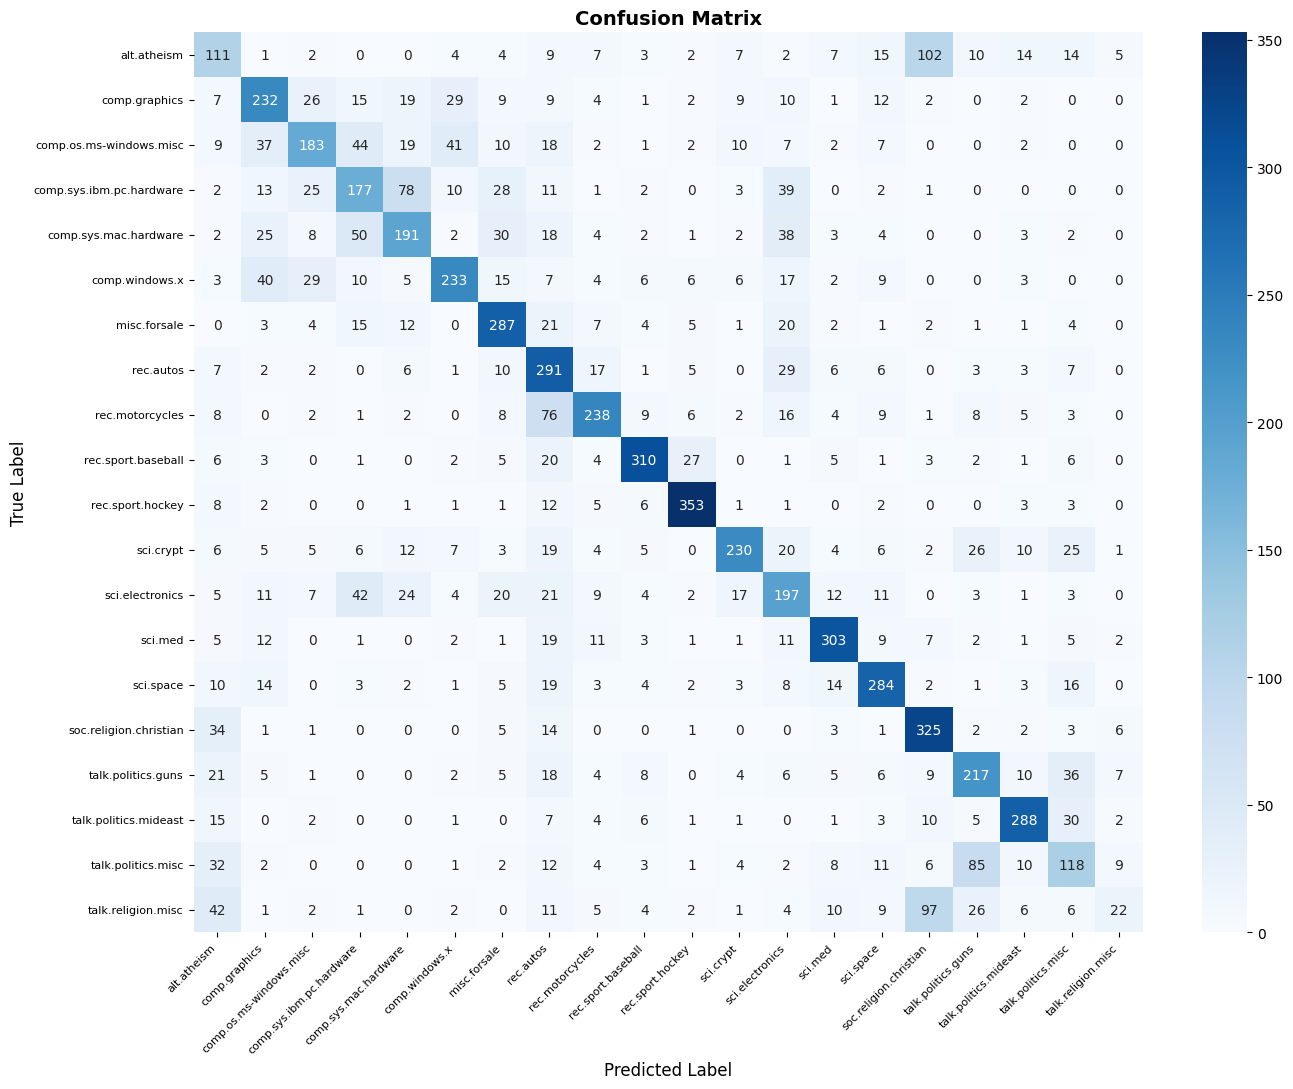

In [10]:
y_pred = np.argmax(model.predict(X_test), axis=1)
target_names = newsgroups_test.target_names

print('Classification Report:\n')
print(classification_report(y_test, y_pred, target_names=target_names,
                             labels=range(len(target_names)), zero_division=0))

# FIX: confusion matrix cell was cut off in the original — completed here
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14, 11))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=target_names, yticklabels=target_names,
            cmap='Blues')
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

## 11. Training & Validation Curves

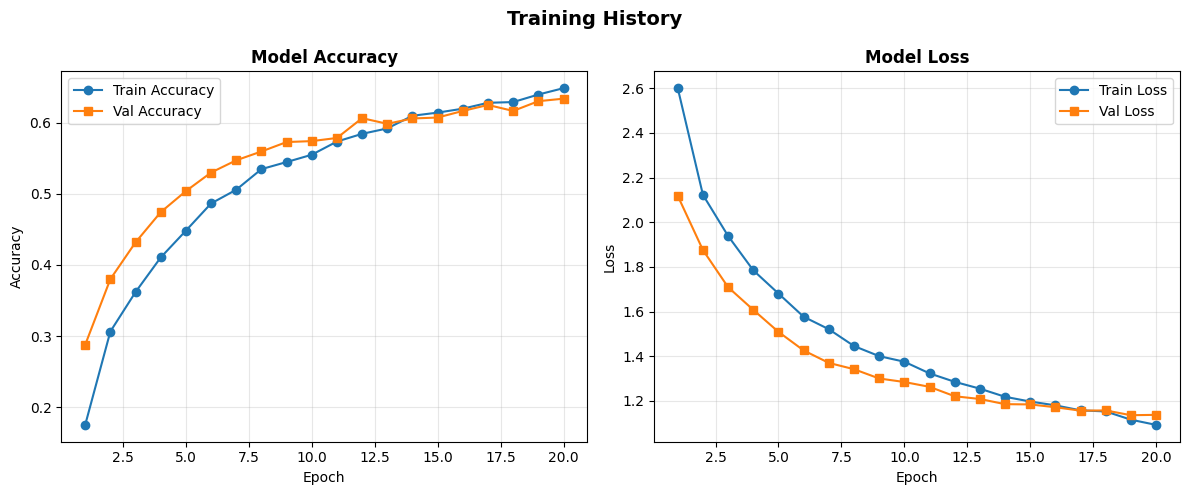

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

epochs_range = range(1, len(history.history['accuracy']) + 1)

axes[0].plot(epochs_range, history.history['accuracy'],     label='Train Accuracy', marker='o')
axes[0].plot(epochs_range, history.history['val_accuracy'], label='Val Accuracy',   marker='s')
axes[0].set_title('Model Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history.history['loss'],     label='Train Loss', marker='o')
axes[1].plot(epochs_range, history.history['val_loss'], label='Val Loss',   marker='s')
axes[1].set_title('Model Loss', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Per-Class F1-Score Bar Chart

Visualises which of the 20 categories the model handles best and worst —
a view that the aggregate accuracy metric cannot provide.

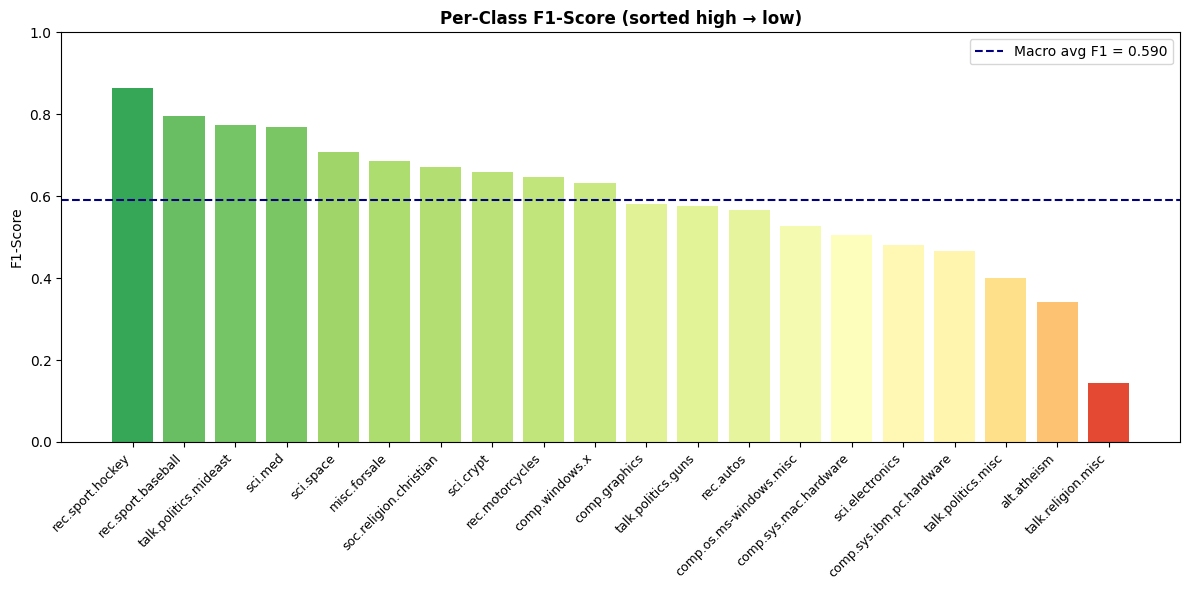

Best category  : rec.sport.hockey                F1=0.863
Worst category : talk.religion.misc              F1=0.144


In [12]:
from sklearn.metrics import f1_score

f1_per_class = f1_score(y_test, y_pred, average=None,
                        labels=range(len(target_names)), zero_division=0)

sorted_idx = np.argsort(f1_per_class)[::-1]
sorted_names = [target_names[i] for i in sorted_idx]
sorted_f1    = f1_per_class[sorted_idx]

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(target_names)), sorted_f1,
               color=plt.cm.RdYlGn(sorted_f1))
plt.xticks(range(len(target_names)), sorted_names, rotation=45, ha='right', fontsize=9)
plt.ylabel('F1-Score')
plt.title('Per-Class F1-Score (sorted high → low)', fontweight='bold')
plt.ylim(0, 1.0)
plt.axhline(y=f1_per_class.mean(), color='navy', linestyle='--',
            label=f'Macro avg F1 = {f1_per_class.mean():.3f}')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Best category  : {target_names[np.argmax(f1_per_class)]:30s}  F1={np.max(f1_per_class):.3f}')
print(f'Worst category : {target_names[np.argmin(f1_per_class)]:30s}  F1={np.min(f1_per_class):.3f}')